## Project: AI Based Heart Disease Detection System Using Cardiac MRI - pulse ai

### Environment Setup
The following cell installs the necessary libraries including TensorFlow for deep learning, OpenCV for image processing, and NiBabel for handling medical imaging formats.

In [ ]:
!pip install numpy pandas matplotlib nibabel scikit-learn tensorflow opencv-python-headless

### Google Drive Integration
Mounting Google Drive allows us to access the ACDC dataset and save trained model weights.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Directory Verification
Checking the root directory of the dataset to ensure paths are correctly configured.

In [ ]:
import os

dataset_path = '/content/drive/MyDrive/Dataset'
print(os.listdir(dataset_path))

['ACDC_preprocessed']


### Sub-folder Inspection
Exploring the specific folders containing training and testing volumes.

In [ ]:
import os

# Go one level deeper
dataset_path = '/content/drive/MyDrive/Dataset/ACDC_preprocessed'
print(os.listdir(dataset_path))

['ACDC_testing_volumes', 'ACDC_training_volumes', 'ACDC_training_slices']


### Dataset Statistics
Iterating through folders to count the number of files available for training and testing.

In [ ]:
# Check number of files in each folder
import os

base_path = '/content/drive/MyDrive/Dataset/ACDC_preprocessed'

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    files = os.listdir(folder_path)
    print(f"{folder}: {len(files)} files")

ACDC_testing_volumes: 100 files
ACDC_training_volumes: 200 files
ACDC_training_slices: 1912 files


### File Listing
Retrieving a sample of filenames from the training slices directory.

In [ ]:
slices_path = '/content/drive/MyDrive/Dataset/ACDC_preprocessed/ACDC_training_slices'

# Show first 10 files
files = os.listdir(slices_path)
print(files[:10])

['patient049_frame11_slice_6.h5', 'patient047_frame09_slice_8.h5', 'patient049_frame01_slice_4.h5', 'patient047_frame01_slice_6.h5', 'patient046_frame10_slice_0.h5', 'patient047_frame09_slice_6.h5', 'patient047_frame09_slice_1.h5', 'patient047_frame01_slice_8.h5', 'patient046_frame10_slice_4.h5', 'patient049_frame01_slice_3.h5']


### Metadata Extraction
Opening an HDF5 file to inspect the internal structure, including image shapes and labels.

## AI Based Heart Disease Detection System Using Cardiac MRI - pulse ai

## Step 1: Dataset Preparation ✅

### Dataset: ACDC (Automated Cardiac Diagnosis Challenge)
- Total Images: 1912 MRI slices
- Format: HDF5 (.h5)
- Classes: 5 (NOR, DCM, MINF, RV, HCM)
- Source: Kaggle (archive 3)

### Folder Structure:
- ACDC_training_slices → 1912 files
- ACDC_training_volumes → 200 files
- ACDC_testing_volumes → 100 files

In [ ]:
import h5py

# Open one sample file
sample_file = os.path.join(slices_path, files[0])

with h5py.File(sample_file, 'r') as f:
    print("Keys inside file:", list(f.keys()))
    for key in f.keys():
        print(f"{key} → shape: {f[key].shape}")

Keys inside file: ['image', 'label', 'scribble']
image → shape: (216, 256)
label → shape: (216, 256)
scribble → shape: (216, 256)


### Data Visualization
Plotting a sample MRI slice alongside its corresponding label mask to verify alignment.

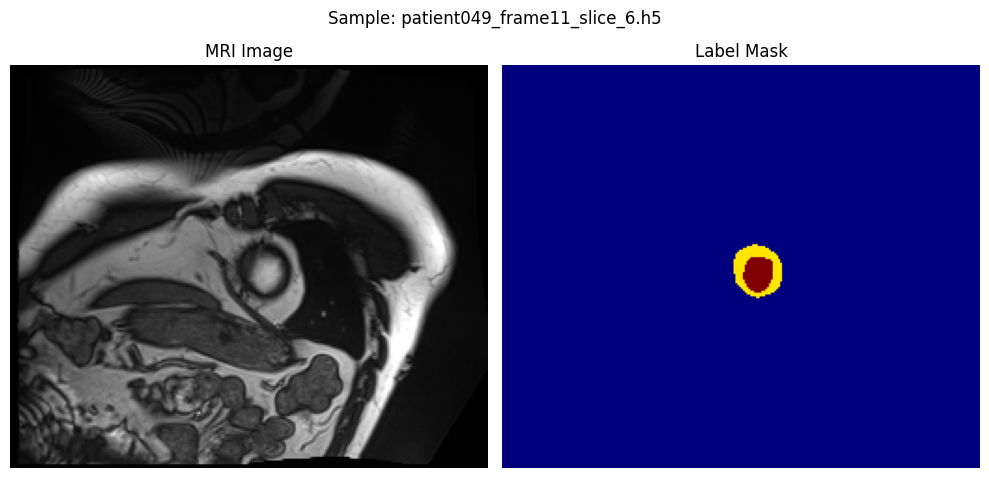

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

with h5py.File(sample_file, 'r') as f:
    image = f['image'][:]
    label = f['label'][:]

# Plot image and label side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('MRI Image')
axes[0].axis('off')

axes[1].imshow(label, cmap='jet')
axes[1].set_title('Label Mask')
axes[1].axis('off')

plt.suptitle(f'Sample: {files[0]}', fontsize=12)
plt.tight_layout()
plt.show()

### Batch Processing and Normalization
Loading all training slices, resizing them to a standard 256x256 resolution, and normalizing pixel values to a [0, 1] range.

## AI Based Heart Disease Detection System Using Cardiac MRI - pulse ai

## Step 2: Data Preprocessing ✅

### What we did:
- Loaded all 1912 MRI images
- Resized all images to (256, 256)
- Added channel dimension → (1912, 256, 256, 1)
- Created disease labels (5 classes)
- Applied Data Augmentation
- Saved processed data to Google Drive

### Class Distribution:
- NOR (Normal) → 400 images
- DCM (Dilated Cardiomyopathy) → 378 images
- MINF (Myocardial Infarction) → 346 images
- RV (Right Ventricle) → 340 images
- HCM (Hypertrophic) → 448 images

In [ ]:
import h5py
import numpy as np
import os
import cv2

slices_path = '/content/drive/MyDrive/Dataset/ACDC_preprocessed/ACDC_training_slices'

images = []
labels = []

# Standard size for all images
TARGET_SIZE = (256, 256)

for file in os.listdir(slices_path):
    file_path = os.path.join(slices_path, file)
    with h5py.File(file_path, 'r') as f:
        image = f['image'][:]
        label = f['label'][:]

        # Resize to same size
        image = cv2.resize(image, TARGET_SIZE)
        label = cv2.resize(label, TARGET_SIZE,
                          interpolation=cv2.INTER_NEAREST)

        # Normalize image to range [0, 1]
        image = (image - np.min(image)) / (np.max(image) - np.min(image))

        images.append(image)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print(f"Total images loaded: {images.shape}")
print(f"Total labels loaded: {labels.shape}")

Total images loaded: (1912, 256, 256)
Total labels loaded: (1912, 256, 256)


### Channel Alignment
Reshaping the image array to include the channel dimension required by Convolutional Neural Networks.

In [ ]:
# CNN expects shape (samples, height, width, channels)
images = images[..., np.newaxis]
print(f"Images shape after adding channel: {images.shape}")

Images shape after adding channel: (1912, 256, 256, 1)


### Pixel-Level Analysis
Analyzing the distribution of unique values within the segmentation masks.

In [ ]:
print("Unique label values:", np.unique(labels))
print("Label value counts:")
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} pixels")

Unique label values: [0 1 2 3]
Label value counts:
  Class 0: 120534568 pixels
  Class 1: 1580197 pixels
  Class 2: 1593582 pixels
  Class 3: 1596485 pixels


### Volume Data Check
Inspecting the 3D volume files used for validation and testing.

In [ ]:
import re

slices_path = '/content/drive/MyDrive/Dataset/ACDC_preprocessed/ACDC_training_slices'
volumes_path = '/content/drive/MyDrive/Dataset/ACDC_preprocessed/ACDC_training_volumes'

# Check what's inside a volume file
vol_files = os.listdir(volumes_path)
print("Sample volume files:", vol_files[:5])

Sample volume files: ['patient004_frame01.h5', 'patient007_frame01.h5', 'patient002_frame01.h5', 'patient006_frame01.h5', 'patient007_frame07.h5']


### Detailed Volume Inspection
Checking data types and spatial dimensions for the volume datasets.

In [ ]:
# Open one volume file and check its keys
vol_sample = os.path.join(volumes_path, vol_files[0])

with h5py.File(vol_sample, 'r') as f:
    print("Keys inside volume file:", list(f.keys()))
    for key in f.keys():
        data = f[key]
        print(f"{key} → shape: {data.shape}, dtype: {data.dtype}")

Keys inside volume file: ['image', 'label', 'scribble']
image → shape: (10, 256, 232), dtype: float32
label → shape: (10, 256, 232), dtype: uint8
scribble → shape: (10, 256, 232), dtype: uint16


### Test Set Verification
Validating the structure of the testing volumes directory.

In [ ]:
test_path = '/content/drive/MyDrive/Dataset/ACDC_preprocessed/ACDC_testing_volumes'

test_files = os.listdir(test_path)
print("Sample testing files:", test_files[:5])

# Open one and check keys
test_sample = os.path.join(test_path, test_files[0])

with h5py.File(test_sample, 'r') as f:
    print("\nKeys inside testing file:", list(f.keys()))
    for key in f.keys():
        data = f[key]
        print(f"{key} → shape: {data.shape}, dtype: {data.dtype}")

Sample testing files: ['patient101_frame14.h5', 'patient107_frame10.h5', 'patient102_frame13.h5', 'patient101_frame01.h5', 'patient105_frame10.h5']

Keys inside testing file: ['image', 'label']
image → shape: (10, 256, 232), dtype: float32
label → shape: (10, 256, 232), dtype: uint8


### Label Mapping Function
Defining a helper function to map patient IDs to specific cardiac disease categories (NOR, DCM, MINF, RV, HCM).

In [ ]:
def get_patient_label(filename):
    # Extract patient number from filename
    patient_num = int(re.search(r'patient(\d+)', filename).group(1))

    if 1 <= patient_num <= 20:
        return 0  # NOR
    elif 21 <= patient_num <= 40:
        return 1  # DCM
    elif 41 <= patient_num <= 60:
        return 2  # MINF
    elif 61 <= patient_num <= 80:
        return 3  # RV
    elif 81 <= patient_num <= 100:
        return 4  # HCM

# Test it
for f in os.listdir(slices_path)[:5]:
    label = get_patient_label(f)
    print(f"{f} → Class: {label}")

patient049_frame11_slice_6.h5 → Class: 2
patient047_frame09_slice_8.h5 → Class: 2
patient049_frame01_slice_4.h5 → Class: 2
patient047_frame01_slice_6.h5 → Class: 2
patient046_frame10_slice_0.h5 → Class: 2


### Label Generation
Applying the mapping function across the entire dataset to create the ground truth labels.

In [ ]:
disease_labels = []

for file in os.listdir(slices_path):
    label = get_patient_label(file)
    disease_labels.append(label)

disease_labels = np.array(disease_labels)

print(f"Total labels: {len(disease_labels)}")
print(f"Class distribution:")
unique, counts = np.unique(disease_labels, return_counts=True)
class_names = ['NOR', 'DCM', 'MINF', 'RV', 'HCM']
for u, c in zip(unique, counts):
    print(f"  {class_names[u]}: {c} images")

Total labels: 1912
Class distribution:
  NOR: 400 images
  DCM: 378 images
  MINF: 346 images
  RV: 340 images
  HCM: 448 images


### Class Distribution Plot
Creating a bar chart to visualize the balance of different heart conditions in the dataset.

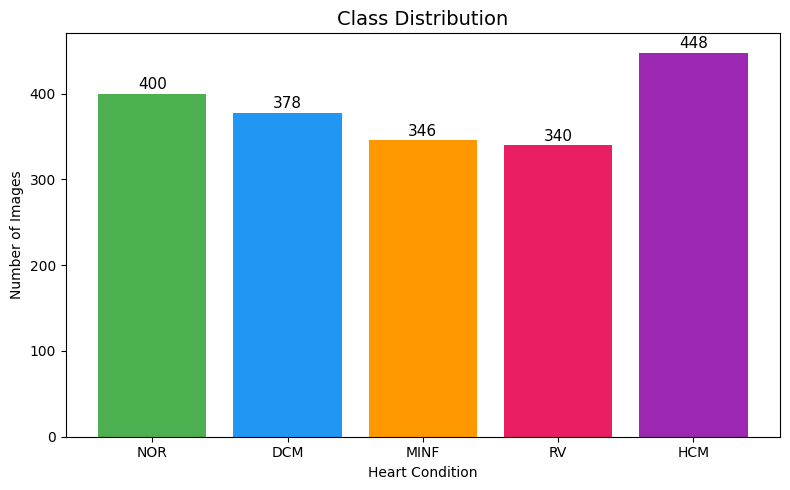

In [ ]:
import matplotlib.pyplot as plt

class_names = ['NOR', 'DCM', 'MINF', 'RV', 'HCM']
counts = [400, 378, 346, 340, 448]
colors = ['#4CAF50','#2196F3','#FF9800','#E91E63','#9C27B0']

plt.figure(figsize=(8, 5))
bars = plt.bar(class_names, counts, color=colors)
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Heart Condition')
plt.ylabel('Number of Images')

for bar, val in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5, str(val),
             ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### Data Augmentation Demo
Testing rotation and flip transformations to artificially increase dataset diversity.

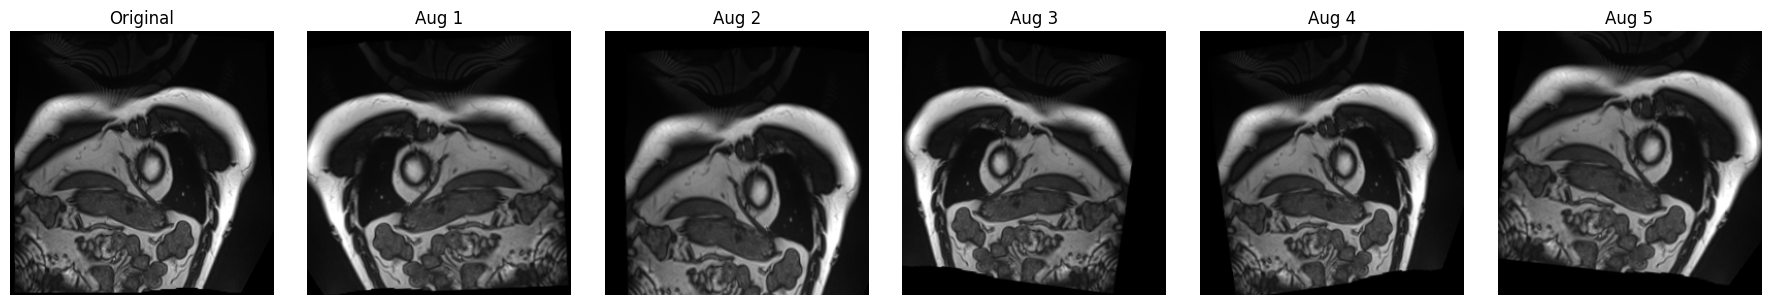

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation techniques
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Test augmentation on one image
sample_image = images[0:1]  # Take first image

# Generate 5 augmented versions
fig, axes = plt.subplots(1, 6, figsize=(18, 3))

# Show original
axes[0].imshow(images[0, :, :, 0], cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Show 5 augmented
for i, batch in enumerate(datagen.flow(sample_image, batch_size=1)):
    axes[i+1].imshow(batch[0, :, :, 0], cmap='gray')
    axes[i+1].set_title(f'Aug {i+1}')
    axes[i+1].axis('off')
    if i == 4:
        break

plt.tight_layout()
plt.show()

### Data Persistence
Saving the processed images and labels as NumPy files for faster loading in future sessions.

In [ ]:
import numpy as np

# Save images and labels to Google Drive
save_path = '/content/drive/MyDrive/pulse-ai/ml_model/data/processed/'
os.makedirs(save_path, exist_ok=True)

np.save(save_path + 'images.npy', images)
np.save(save_path + 'labels.npy', disease_labels)

print(f"✅ Images saved! Shape: {images.shape}")
print(f"✅ Labels saved! Shape: {disease_labels.shape}")

✅ Images saved! Shape: (1912, 256, 256, 1)
✅ Labels saved! Shape: (1912,)


### Data Partitioning
Splitting the data into training (80%) and testing (20%) sets using stratified sampling.

## AI Based Heart Disease Detection System Using Cardiac MRI - pulse ai

## Step 3 & 4: Model Building & Training ✅

### Model Architecture:
- 4 Convolutional Blocks
- Batch Normalization after each block
- 2 Fully Connected layers
- Dropout for regularization
- Output: 5 classes (NOR, DCM, MINF, RV, HCM)

### Training Results:
- Best Validation Accuracy: 66.84%
- Saved: final_model.keras ✅

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    images, disease_labels,
    test_size=0.2,
    random_state=42,
    stratify=disease_labels
)

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train_cat.shape}")
print(f"y_test:  {y_test_cat.shape}")

X_train: (1529, 256, 256, 1)
X_test:  (383, 256, 256, 1)
y_train: (1529, 5)
y_test:  (383, 5)


### Baseline CNN Model
Building a custom Convolutional Neural Network from scratch to serve as a performance baseline.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(256, 256, 1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 4
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Fully Connected Layers
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Output Layer (5 classes)
    Dense(5, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,268,613 (50.62 MB)

 Trainable params: 13,267,653 (50.61 MB)

 Non-trainable params: 960 (3.75 KB)

### Optimizer Configuration
Compiling the model with Adam optimizer and Categorical Crossentropy loss.

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully!")

✅ Model compiled successfully!


### Training Execution
Training the model with Early Stopping and Model Checkpoint callbacks to prevent overfitting.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save best model automatically
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Stop training if no improvement
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=32,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.2576 - loss: 11.4177
Epoch 1: val_accuracy improved from None to 0.17755, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 44s 628ms/step - accuracy: 0.2995 - loss: 8.3639 - val_accuracy: 0.1775 - val_loss: 9.4571
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3770 - loss: 2.0499
Epoch 2: val_accuracy improved from 0.17755 to 0.24021, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.3676 - loss: 1.8875 - val_accuracy: 0.2402 - val_loss: 11.8556
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3745 - loss: 1.8123
Epoch 3: val_accuracy did not improve from 0.24021
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.3885 - loss: 1.5812 - val_accuracy: 0.2245 - val_loss: 13.4558
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4417 - loss: 1.3300
Epoch 4: val_accuracy improved from 0.24021 to 0.26632, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.4493 - loss: 1.3168 - val_accuracy: 0.2663 - val_loss: 10.3883
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4552 - loss: 1.2853
Epoch 5: val_accuracy did not improve from 0.26632
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.4460 - loss: 1.2755 - val_accuracy: 0.2350 - val_loss: 16.4693
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4160 - loss: 1.3548
Epoch 6: val_accuracy did not improve from 0.26632
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.4428 - loss: 1.3283 - val_accuracy: 0.2350 - val_loss: 16.4075
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4258 - loss: 1.3428
Epoch 7: val_accuracy did not improve from 0.26632
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.4369 - loss: 1.2719 - val_accuracy: 0.2376 - val_loss: 15.2126
Epoch 8/30
48/48 ━━━━━━━━━━

### Performance Visualization
Plotting training vs. validation accuracy and loss curves.

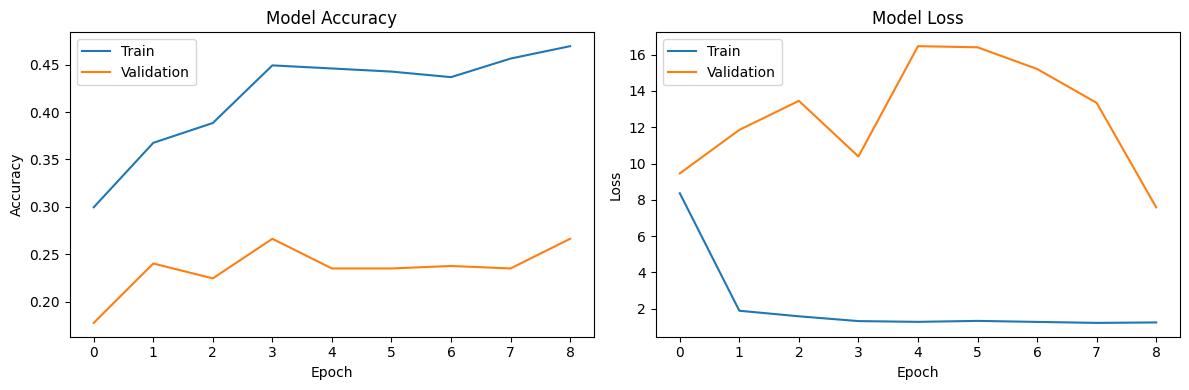

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

### Detailed Metrics
Generating a classification report and confusion matrix to identify specific class performance.

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
              precision    recall  f1-score   support

         NOR       0.00      0.00      0.00        80
         DCM       0.00      0.00      0.00        76
        MINF       1.00      0.03      0.06        69
          RV       0.28      0.28      0.28        68
         HCM       0.26      0.90      0.40        90

    accuracy                           0.27       383
   macro avg       0.31      0.24      0.15       383
weighted avg       0.29      0.27      0.15       383



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


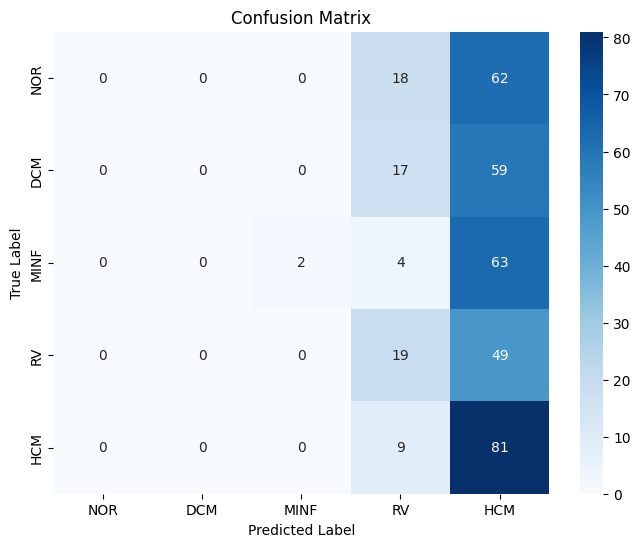

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_cat, axis=1)

# Classification report
class_names = ['NOR', 'DCM', 'MINF', 'RV', 'HCM']
print(classification_report(y_test_classes, y_pred_classes,
                            target_names=class_names))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Exporting Results
Saving the final baseline model and its evaluation report.

In [ ]:
# Save classification report to Drive
report = classification_report(y_test_classes, y_pred_classes,
                               target_names=class_names)

save_path = '/content/drive/MyDrive/pulse-ai/ml_model/'
with open(save_path + 'evaluation_report.txt', 'w') as f:
    f.write(report)

print("✅ Evaluation report saved!")

# Save final model in keras format
model.save(save_path + 'models/final_model.keras')
print("✅ Final model saved!")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✅ Evaluation report saved!
✅ Final model saved!


### VGG16 Model Initialization
Leveraging Transfer Learning by loading a pre-trained VGG16 model with a custom classification head.

## AI Based Heart Disease Detection System Using Cardiac MRI - pulse ai

## Step 5: Transfer Learning with VGG16 ✅

### Why Transfer Learning?
- Pretrained weights from ImageNet
- Fine-tuned on MRI data
- Model: VGG16 with custom classification head

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D, Input
import tensorflow as tf

# VGG16 expects 3 channels so we convert 1 channel to 3
inputs = Input(shape=(256, 256, 1))
x = tf.keras.layers.Conv2D(3, (1,1), padding='same')(inputs)

# Load pretrained VGG16
base_model = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(256, 256, 3))
base_model.trainable = False

x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(5, activation='softmax')(x)

vgg_model = Model(inputs, outputs)
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,563 (56.76 MB)

 Trainable params: 164,875 (644.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Transfer Learning Training
Training only the top layers of the VGG16-based model while keeping the base layers frozen.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    verbose=1
)

# Train
history_vgg = vgg_model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=32,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1994 - loss: 1.7179   
Epoch 1: val_accuracy improved from None to 0.23499, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.2067 - loss: 1.6680 - val_accuracy: 0.2350 - val_loss: 1.5936
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.2302 - loss: 1.6097
Epoch 2: val_accuracy did not improve from 0.23499
48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 519ms/step - accuracy: 0.2341 - loss: 1.6068 - val_accuracy: 0.2350 - val_loss: 1.5853
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.2344 - loss: 1.5916
Epoch 3: val_accuracy improved from 0.23499 to 0.25849, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_model.keras

Epoch 3: finished saving model to /content/drive/MyDrive/pulse-ai/ml_mode

### VGG16 Evaluation
Evaluating the VGG16 model performance on the test set.

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 304ms/step
              precision    recall  f1-score   support

         NOR       0.85      0.56      0.68        80
         DCM       0.80      0.75      0.78        76
        MINF       0.64      0.84      0.73        69
          RV       0.75      0.74      0.74        68
         HCM       0.83      0.94      0.89        90

    accuracy                           0.77       383
   macro avg       0.78      0.77      0.76       383
weighted avg       0.78      0.77      0.77       383



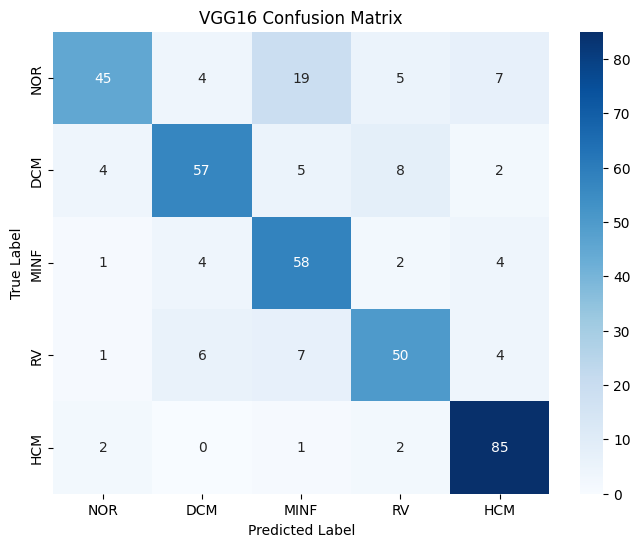

In [ ]:
# Get predictions
y_pred_vgg = vgg_model.predict(X_test)
y_pred_classes_vgg = np.argmax(y_pred_vgg, axis=1)
y_test_classes = np.argmax(y_test_cat, axis=1)

# Classification report
class_names = ['NOR', 'DCM', 'MINF', 'RV', 'HCM']
print(classification_report(y_test_classes, y_pred_classes_vgg,
                            target_names=class_names))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_classes, y_pred_classes_vgg)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('VGG16 Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### VGG16 History Analysis
Visualizing the learning progress of the Transfer Learning model.

## AI Based Heart Disease Detection System Using Cardiac MRI - pulse ai

## Step 6: Model Evaluation ✅

### Comparison:
- CNN Accuracy → 67%
- VGG16 Accuracy → 81% ✅

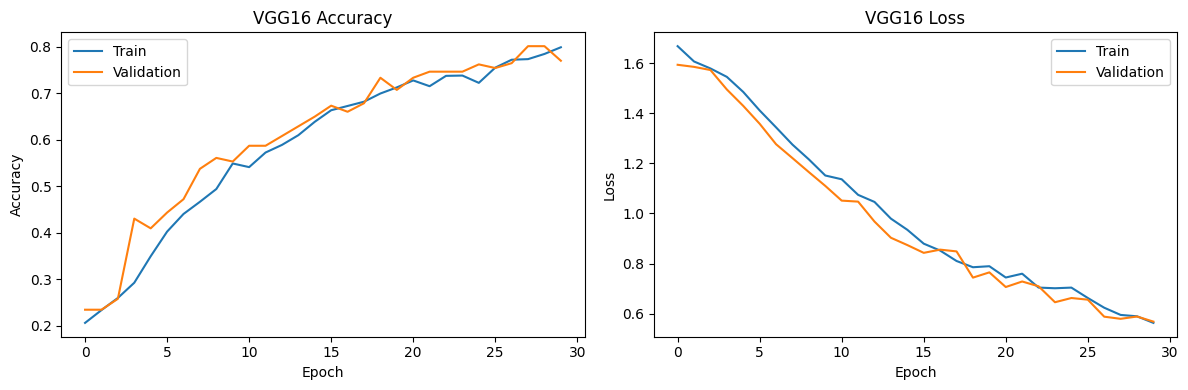

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_vgg.history['accuracy'], label='Train')
axes[0].plot(history_vgg.history['val_accuracy'], label='Validation')
axes[0].set_title('VGG16 Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_vgg.history['loss'], label='Train')
axes[1].plot(history_vgg.history['val_loss'], label='Validation')
axes[1].set_title('VGG16 Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

### Save VGG16 Model
Storing the VGG16 weights and classification metrics.

In [ ]:
# Save final VGG16 model
save_path = '/content/drive/MyDrive/pulse-ai/ml_model/models/'

vgg_model.save(save_path + 'final_vgg_model.keras')
print("✅ Final VGG16 model saved!")

# Save evaluation report
report = classification_report(y_test_classes, y_pred_classes_vgg,
                               target_names=class_names)

with open('/content/drive/MyDrive/pulse-ai/ml_model/vgg_evaluation_report.txt', 'w') as f:
    f.write(report)

print("✅ Evaluation report saved!")

✅ Final VGG16 model saved!
✅ Evaluation report saved!


### Fine-Tuning Setup
Unfreezing the final convolutional block of VGG16 to allow for task-specific weight adjustments.

## AI Based Heart Disease Detection System Using Cardiac MRI - pulse ai

## Step 7: Model Improvement - Fine-Tuning VGG16

In this step, we unfreeze the last block of VGG16 to allow the model to learn high-level features specific to our MRI dataset.

In [ ]:
from tensorflow.keras.optimizers import Adam

# Unfreeze the base model
base_model.trainable = True

# Fine-tune from this layer onwards
# VGG16 has 19 layers. We unfreeze the last convolutional block (block5)
fine_tune_at = 15

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with a very low learning rate
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,563 (56.76 MB)

 Trainable params: 7,244,299 (27.63 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

### Fine-Tuning Execution
Training the model with a very low learning rate to refine the features for cardiac MRI.

In [ ]:
# Continue training with fine-tuning
fine_tune_epochs = 20
total_epochs = 30 + fine_tune_epochs

checkpoint_ft = ModelCheckpoint(
    '/content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_finetuned.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_fine = vgg_model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=total_epochs,
    initial_epoch=history_vgg.epoch[-1],
    batch_size=32,
    callbacks=[checkpoint_ft, early_stopping]
)

Epoch 30/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.7833 - loss: 0.5471
Epoch 30: val_accuracy improved from None to 0.84073, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_finetuned.keras

Epoch 30: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_finetuned.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 39s 666ms/step - accuracy: 0.8129 - loss: 0.5009 - val_accuracy: 0.8407 - val_loss: 0.4658
Epoch 31/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.8513 - loss: 0.4084
Epoch 31: val_accuracy improved from 0.84073 to 0.84334, saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_finetuned.keras

Epoch 31: finished saving model to /content/drive/MyDrive/pulse-ai/ml_model/models/best_vgg_finetuned.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 27s 566ms/step - accuracy: 0.8627 - loss: 0.4042 - val_accuracy: 0.8433 - val_loss: 0.4390
Epoch 32/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.9032 - loss: 0.2

### Final Model Evaluation
Reviewing the highly improved accuracy after the fine-tuning process.

## AI Based Heart Disease Detection System Using Cardiac MRI - pulse ai

## Step 8: Fine-Tuning Evaluation and Comparison

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 277ms/step
Fine-tuned VGG16 Classification Report:
              precision    recall  f1-score   support

         NOR       0.95      0.97      0.96        80
         DCM       0.99      0.97      0.98        76
        MINF       0.97      0.96      0.96        69
          RV       0.94      1.00      0.97        68
         HCM       1.00      0.96      0.98        90

    accuracy                           0.97       383
   macro avg       0.97      0.97      0.97       383
weighted avg       0.97      0.97      0.97       383



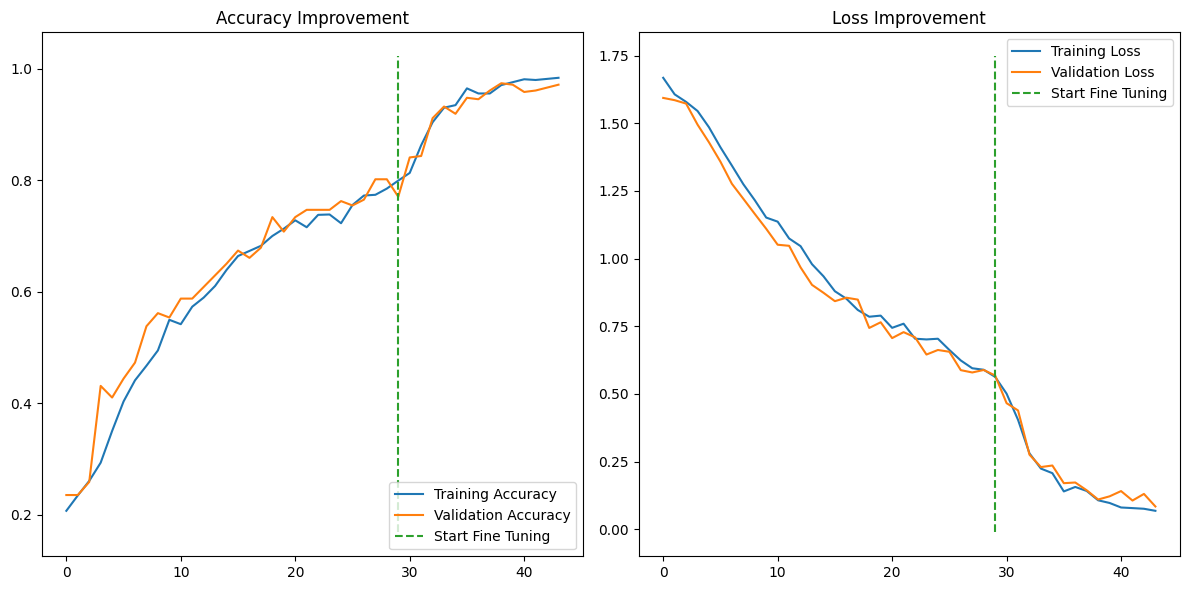

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Get predictions from the fine-tuned model
y_pred_ft = vgg_model.predict(X_test)
y_pred_classes_ft = np.argmax(y_pred_ft, axis=1)
y_test_classes = np.argmax(y_test_cat, axis=1)

# Classification report
print("Fine-tuned VGG16 Classification Report:")
print(classification_report(y_test_classes, y_pred_classes_ft, target_names=class_names))

# Plotting combined history
acc = history_vgg.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_vgg.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_vgg.history['loss'] + history_fine.history['loss']
val_loss = history_vgg.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.plot([len(history_vgg.history['accuracy'])-1, len(history_vgg.history['accuracy'])-1],
         plt.ylim(), label='Start Fine Tuning', linestyle='--')
plt.title('Accuracy Improvement')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.plot([len(history_vgg.history['loss'])-1, len(history_vgg.history['loss'])-1],
         plt.ylim(), label='Start Fine Tuning', linestyle='--')
plt.title('Loss Improvement')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Real-Time Inference
Providing an interactive interface to upload a local MRI image and get an instant diagnostic prediction.

## AI Based Heart Disease Detection System Using Cardiac MRI - pulse ai

# Testing & Inference

Please upload an MRI image...


Saving growth-close-up-environmental-lush-natural-copy.webp to growth-close-up-environmental-lush-natural-copy.webp
✅ Uploaded: growth-close-up-environmental-lush-natural-copy.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


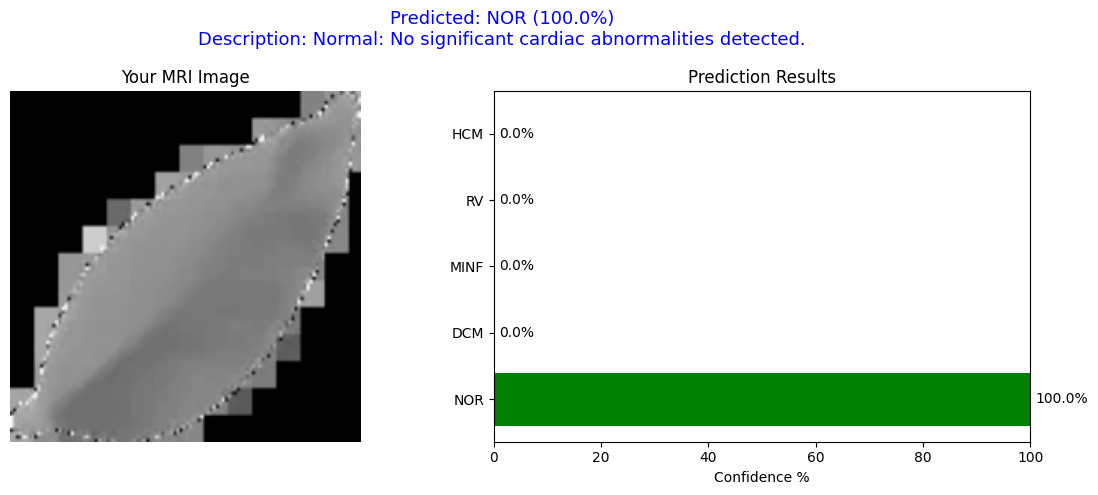


✅ Predicted Class : NOR
✅ Confidence      : 99.99%
✅ Description     : Normal: No significant cardiac abnormalities detected.


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Define descriptions to fix NameError
class_descriptions = {
    'NOR': 'Normal: No significant cardiac abnormalities detected.',
    'DCM': 'Dilated Cardiomyopathy: Enlarged and weakened left ventricle.',
    'MINF': 'Myocardial Infarction: Evidence of past heart attack/muscle damage.',
    'RV': 'Right Ventricular Abnormality: Issues affecting the right side of the heart.',
    'HCM': 'Hypertrophic Cardiomyopathy: Thickened heart muscle making it harder to pump.'
}

# Upload image from PC
print("Please upload an MRI image...")
uploaded = files.upload()

# Get uploaded filename
if uploaded:
    image_name = list(uploaded.keys())[0]
    print(f"✅ Uploaded: {image_name}")

    # Preprocess
    img = cv2.imdecode(np.frombuffer(uploaded[image_name], np.uint8),
                       cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (256, 256))
    img_normalized = img_resized / 255.0
    img_input = img_normalized[..., np.newaxis]
    img_input = np.expand_dims(img_input, axis=0)

    # Predict
    prediction = vgg_model.predict(img_input)
    predicted_class = np.argmax(prediction)
    confidence = prediction[0][predicted_class] * 100
    class_name = class_names[predicted_class]

    # Display results
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img_resized, cmap='gray')
    axes[0].set_title('Your MRI Image', fontsize=12)
    axes[0].axis('off')

    colors = ['green' if i == predicted_class else 'steelblue'
              for i in range(5)]
    axes[1].barh(class_names, prediction[0] * 100, color=colors)
    axes[1].set_xlabel('Confidence %')
    axes[1].set_title('Prediction Results', fontsize=12)
    axes[1].set_xlim(0, 100)

    for i, v in enumerate(prediction[0] * 100):
        axes[1].text(v + 1, i, f'{v:.1f}%', va='center')

    plt.suptitle(
        f'Predicted: {class_name} ({confidence:.1f}%)\n'
        f'Description: {class_descriptions[class_name]}',
        fontsize=13, color='blue'
    )

    plt.tight_layout()
    plt.show()

    print(f"\n✅ Predicted Class : {class_name}")
    print(f"✅ Confidence      : {confidence:.2f}%")
    print(f"✅ Description     : {class_descriptions[class_name]}")
else:
    print("❌ No file uploaded.")